In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import model as md


#A FAIRE


### Method A plots à faire: 
# mu=0.1 over vs lambda2,  
# mu =2 over vs lambda1,  
# rho eleve (~0.6) over vs mu; 
# comparer H et 2mu F1
## CV sur mu  
# 2D: mu vs LAM1: mu opt/croisement ligne rouge
### Dans le overleaf:
# C= 1/n [[1, rho][rho, 1]] dans overleaf, 

### si le temps (-> goal absolu):
# comparer fisher theo et empirique, 


In [141]:

def fisher_MS(x, lam):
    N = len(x)
    return ((lam - 1)**2 + 1/N)*np.outer(x, x) + np.eye(N)/N

import numpy as np
import matplotlib.pyplot as plt

def cv_mu(N, rho, lambda1, lambda2, MU, method, M, solve=True, verbose=True, plot=True):
    results = {
        "A": {"over1": [], "over2": [], "std1": [], "std2": []},
        "B": {"over1": [], "over2": [], "std1": [], "std2": []}
    }

    for mu in MU:
        mA1, mA2, mB1, mB2 = [], [], [], []

        for _ in range(M):
            _, thetaA, thetaB, x1, x2 = x_fisher(
                N=N, rho=rho, lambda1=lambda1, lambda2=lambda2,
                mu=mu, method=method, solve=solve
            )

            mA1.append(abs(np.dot(thetaA, x1)))
            mA2.append(abs(np.dot(thetaA, x2)))
            mB1.append(abs(np.dot(thetaB, x1)))
            mB2.append(abs(np.dot(thetaB, x2)))

   
        for key, arr in zip(["over1", "over2"], [mA1, mA2]):
            results["A"][key].append(np.mean(arr))
            results["A"][f"std{key[-1]}"].append(np.std(arr) / np.sqrt(M))

        for key, arr in zip(["over1", "over2"], [mB1, mB2]):
            results["B"][key].append(np.mean(arr))
            results["B"][f"std{key[-1]}"].append(np.std(arr) / np.sqrt(M))

        if verbose:
            if method == "both":
                print(f"mu={mu:.4f} | A: ({results['A']['over1'][-1]:.4f}, {results['A']['over2'][-1]:.4f}) "
                    f"| B: ({results['B']['over1'][-1]:.4f}, {results['B']['over2'][-1]:.4f})")
            elif method == "A":
                print(f"mu={mu:.4f} | A: ({results['A']['over1'][-1]:.4f}, {results['A']['over2'][-1]:.4f})")
  
    scoreA = np.array(results["A"]["over1"]) + np.array(results["A"]["over2"])
    scoreB = np.array(results["B"]["over1"]) + np.array(results["B"]["over2"])

    mu_optA = MU[np.argmax(scoreA)]
    mu_optB = MU[np.argmax(scoreB)]

    print("\n mu optimal A:", mu_optA)
    print(" mu optimal B:", mu_optB)

    if plot:
        plt.figure()

        plt.errorbar(MU, results["A"]["over1"], yerr=results["A"]["std1"], label="A over1")
        plt.errorbar(MU, results["A"]["over2"], yerr=results["A"]["std2"], linestyle="--", label="A over2")

        #plt.errorbar(MU, results["B"]["over1"], yerr=results["B"]["std1"], label="B over1")
        #plt.errorbar(MU, results["B"]["over2"], yerr=results["B"]["std2"], linestyle="--", label="B over2")

        plt.axvline(mu_optA, linestyle=":", label="mu_optA")
        #plt.axvline(mu_optB, linestyle=":", label="mu_optB")

        plt.xlabel("mu")
        plt.ylabel("overlap")
        plt.legend()
        plt.title("Cross-validation sur mu")
        plt.show()

    return mu_optA, mu_optB, results
 
def power_iteration(M, x_hat, iterations=50, tol=1e-7):
        for _ in range(iterations):
            x_new = M @ x_hat   # single mat-vec, O(N²)
            x_new /= np.linalg.norm(x_new)
            if np.linalg.norm(x_new - x_hat) < tol:
                break
            x_hat = x_new
        return x_hat

def x_fisher(N, rho, lambda1, lambda2, mu, method, solve = True):
    Y1, Y2, x1, x2 = md.spiked_gaussian_matrix_with_correlated_spikes(N, lambda1, lambda2, rho)

    theta1 = np.ones(N)
    theta1 = power_iteration(Y1, theta1)

    F1 = fisher_MS(theta1, lambda1)
    A = Y2 - np.eye(N) + 2*mu*F1

    thetaA = np.zeros(N)
    thetaB = np.zeros(N)

    if method in ("A", "both"):
        thetaA = np.ones(N)
        thetaA = power_iteration(A, thetaA)

    if method in ("B", "both"):
        b = 2*mu * F1 @ theta1
        if solve:
            thetaB = np.linalg.solve(A, b)
        else: 
            if np.linalg.cond(A) < 1e12 :
                thetaB = np.linalg.inv(A) @ b
            else :
                print( " det A = 0")
                print( "cond : " , np.linalg.cond(A) )
        thetaB /= np.linalg.norm(thetaB)
    return theta1, thetaA, thetaB, x1, x2


def ecart_F_xhat_x1(N, rho, lambda1, lambda2, M=10):
    norm = []
    for _ in range (M):
        Y1, Y2, x1, x2 = md.spiked_gaussian_matrix_with_correlated_spikes(N, lambda1, lambda2, rho)

        theta1 = np.ones(N)
        theta1 = power_iteration(Y1, theta1)

        Fhat = fisher_MS(theta1, lambda1)
        F = fisher_MS(x1, lambda1)
        norm += [np.linalg.norm(Fhat - F, 'fro')/np.linalg.norm(F, 'fro')]
    norm = np.array(norm)
    return np.mean(norm), np.std(norm)/np.sqrt(M)


def analyse_Hess_Fisher(N, rho, lambda1, lambda2, mu, estim = False, spectre = True):
    Y1, Y2, x1, x2 = md.spiked_gaussian_matrix_with_correlated_spikes(N, lambda1, lambda2, rho)

    if estim:
        theta1 = np.ones(N)
        theta1 = power_iteration(Y1, theta1)
    
        F1 = fisher_MS(theta1, lambda1)
    else : 
        F1 = fisher_MS(x1, lambda1)
    
    A = Y2 - np.eye(N) + 2*mu*F1

    detF1 = np.linalg.det(F1)
    detH = np.linalg.det(A)


    if spectre:
        eigF1 = np.linalg.eigvals(F1)
        eigH = np.linalg.eigvals(A)
    
        plt.hist(eigF1, bins=100, density=False, alpha=0.5)
        plt.title(f"Fisher spectrum; det={detF1}")
        plt.xlabel("Eigenvalues")
        plt.show()

        plt.hist(eigH, bins=100, density=False, alpha=0.5)
        plt.xlabel("Eigenvalues")
        plt.title(f"Hessian spectrum; det={detH}")
        plt.show()

    return detF1, detH

def ploplot(title, ylabel, lam_vals, yA, stdA, yB, stdB, ybase=None, stdbase=None):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.errorbar(lam_vals, yA, yerr=stdA, fmt='o-', capsize=4,
                color='steelblue', label='Method A', linewidth=1.5, markersize=5)
    ax.errorbar(lam_vals, yB, yerr=stdB, fmt='s-', capsize=4,
                color='tomato', label='Method B', linewidth=1.5, markersize=5)

    if ybase is not None:
        ax.errorbar(lam_vals, ybase, yerr=stdbase, fmt='D--', capsize=4,
                    color='gray', label=r'Step1 $\theta_1$', linewidth=1.5, markersize=5)

    ax.axvline(x=1, color='black', linestyle=':', linewidth=1, label=r'$\lambda=1$')
    ax.set_xlabel(r'$\lambda_1$', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()



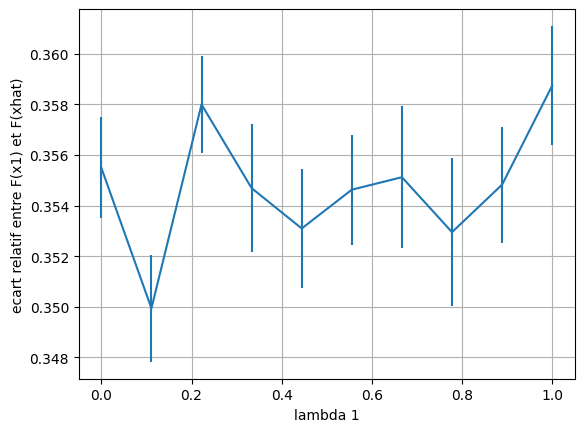

In [ ]:

rho = 0.2
RHO = np.linspace(0, 1, 10)

lambda1 = 4
LAM1 = np.linspace(2, 20, 20)

lambda2 = 3

N = 1000
Nvary = np.linspace(500, 5000, 10, dtype = int)

mu = 1
MU = np.linspace(0.1, 100, 20)

M = 10

ecart = []

for rho in RHO:
    ecart += [ecart_F_xhat_x1(N, rho, lambda1, lambda2, M=10)]

ecart = np.array(ecart)
plt.errorbar(RHO, ecart[:, 0], ecart[:,1])
plt.grid()
plt.ylabel("ecart relatif entre F(x1) et F(xhat)")
plt.xlabel("lambda 1")
plt.show()

mu=1.0000 | A: (0.6581, 0.9907)
mu=2.0000 | A: (0.7191, 0.9754)
mu=3.0000 | A: (0.7676, 0.9467)
mu=4.0000 | A: (0.8096, 0.9093)
mu=5.0000 | A: (0.8406, 0.8702)
mu=6.0000 | A: (0.8584, 0.8348)
mu=7.0000 | A: (0.8722, 0.7957)
mu=8.0000 | A: (0.8762, 0.7660)
mu=9.0000 | A: (0.8770, 0.7420)
mu=10.0000 | A: (0.8789, 0.7124)

 mu optimal A: 4.0
 mu optimal B: 1.0


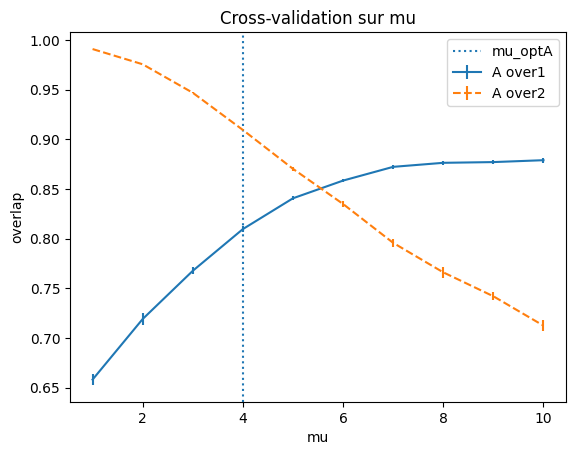

(np.float64(4.0),
 np.float64(1.0),
 {'A': {'over1': [np.float64(0.6581385563553919),
    np.float64(0.719068753970485),
    np.float64(0.7675661616366586),
    np.float64(0.8095587116691185),
    np.float64(0.8405593866681815),
    np.float64(0.8583637185063704),
    np.float64(0.872182687373041),
    np.float64(0.8762345374376688),
    np.float64(0.8769702566929591),
    np.float64(0.8788766054151669)],
   'over2': [np.float64(0.990697672631381),
    np.float64(0.9753756869937785),
    np.float64(0.9467154917846843),
    np.float64(0.9093051165037511),
    np.float64(0.8701906379722673),
    np.float64(0.8348110867730645),
    np.float64(0.795692087186802),
    np.float64(0.7660257884405963),
    np.float64(0.7419549678011907),
    np.float64(0.7123961882555674)],
   'std1': [np.float64(0.005371584489616149),
    np.float64(0.005696032387627573),
    np.float64(0.0034285634253462243),
    np.float64(0.003422722579327495),
    np.float64(0.002062091202512775),
    np.float64(0.0018623

In [153]:
lambda1 = 2 # mu opt pour 2mu (lambda1 -1)**2 = lambda2
lambda2 = 10

## mu optimal 
rho = 0.6
MU = np.linspace(1, 10, 10)
cv_mu(N, rho, lambda1, lambda2, MU,  "A" , M, solve=True, verbose=True, plot=True)

In [76]:

N = 1000
lambda2 = 2
lambda1 = 3
mu = 1
MU = np.linspace(0.1, 3, 4)
rho = 0.2
LAM1 = np.linspace(0.1, 5, 20)
M = 10

results = {
    "A": {"over1": [], "over2": [], "std1": [], "std2": []},
    "B": {"over1": [], "over2": [], "std1": [], "std2": []},
    "step1": {"over1": [], "std1": []},
}

for mu in MU:
    mA1, mA2, mB1, mB2, mstep1 = [], [], [], [], []

    for _ in range(M):
        theta1, thetaA, thetaB, x1, x2 = x_fisher(N = N, rho = rho, lambda1 = lambda1, lambda2 = lambda2, 
                                                  mu = mu, method = "both", solve = False)

        mA1.append(abs(np.dot(thetaA, x1)))
        mA2.append(abs(np.dot(thetaA, x2)))
        mB1.append(abs(np.dot(thetaB, x1)))
        mB2.append(abs(np.dot(thetaB, x2)))
        mstep1.append(abs(np.dot(theta1, x1)))

    for key, arr in zip(["over1", "over2"], [mA1, mA2]):
        results["A"][key].append(np.mean(arr))
        results["A"][f"std{key[-1]}"].append(np.std(arr) / np.sqrt(M))

    for key, arr in zip(["over1", "over2"], [mB1, mB2]):
        results["B"][key].append(np.mean(arr))
        results["B"][f"std{key[-1]}"].append(np.std(arr) / np.sqrt(M))

    results["step1"]["over1"].append(np.mean(mstep1))
    results["step1"]["std1"].append(np.std(mstep1) / np.sqrt(M))



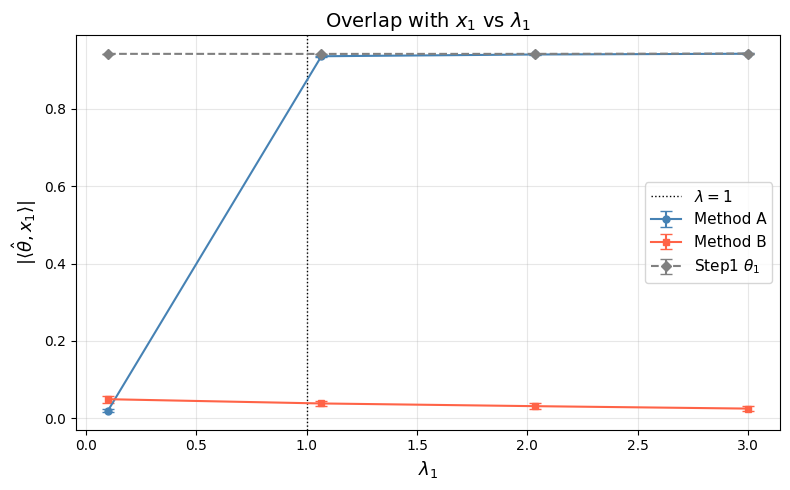

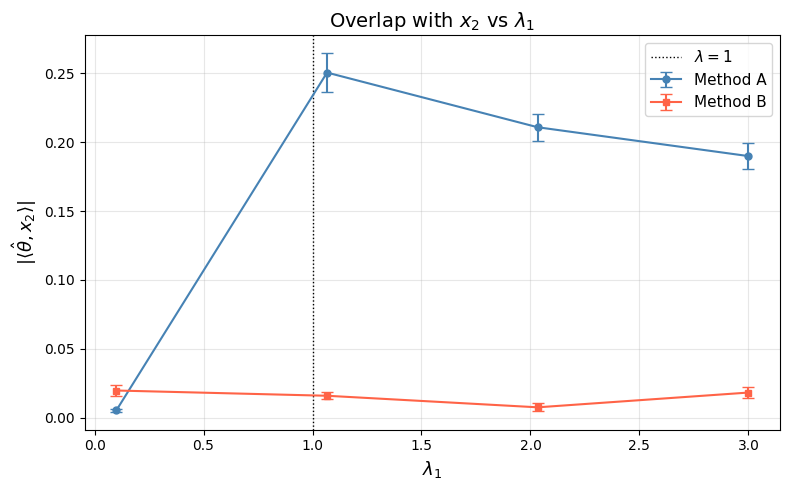

In [77]:
ploplot(
    title=r'Overlap with $x_1$ vs $\lambda_1$',
    ylabel=r'$|\langle \hat{\theta}, x_1 \rangle|$',
    lam_vals=MU,
    yA=results["A"]["over1"], stdA=results["A"]["std1"],
    yB=results["B"]["over1"], stdB=results["B"]["std1"],
    ybase=results["step1"]["over1"], stdbase=results["step1"]["std1"],
)

ploplot(
    title=r'Overlap with $x_2$ vs $\lambda_1$',
    ylabel=r'$|\langle \hat{\theta}, x_2 \rangle|$',
    lam_vals=MU,
    yA=results["A"]["over2"], stdA=results["A"]["std2"],
    yB=results["B"]["over2"], stdB=results["B"]["std2"],
)

In [32]:
def run_experiment_2D(vary_param_x, vary_values_x, vary_param_y, vary_values_y, 
                       M, n, k1, k2, rho, alpha, method, methodF = "A", all_overlap = True, plot = True):
    
    Z11    = np.zeros((len(vary_values_y), len(vary_values_x)))
    Z22   = np.zeros((len(vary_values_y), len(vary_values_x)))
    Z12 = np.zeros((len(vary_values_y), len(vary_values_x)))
    Z21 = np.zeros((len(vary_values_y), len(vary_values_x)))

    for i, val_y in enumerate(vary_values_y):
        for j, val_x in enumerate(vary_values_x):
            params = {'n': n, 'k1': k1, 'k2': k2, 'rho': rho, 'alpha': alpha}
            params[vary_param_x] = val_x
            params[vary_param_y] = val_y

            over11, over22, over12, over21 = [], [], [], []
            for _ in range(M):
                Y1, Y2, x1, x2 = md.spiked_gaussian_matrix_with_correlated_spikes(params['n'], params['k1'],  params['k2'], params['rho'])
                D = params['alpha'] * Y1 + np.sqrt(1 - params['alpha']**2)*Y2
                D, x1, x2 = md.spec(params['n'], params['k1'], params['k2'], 
                                      params['rho'], params['alpha'])
                if method == "naive": 
                    m11, m22, m12, m21 = md.overlap(D, x1, x2, all_overlap)
                elif method == "fisher":
                    theta1, thetaA, thetaB, x1, x2 = x_fisher(N, rho, lambda1, lambda2, mu, method = methodF)
                    m11 = abs(np.dot(thetaA,x1))
                    m12 = abs(np.dot(thetaA,x2))
                    m21 = abs(np.dot(thetaB,x1))
                    m22 = abs(np.dot(thetaB,x2))
                else: 
                    m11, m12, m22, m21 = 0  
                     
                over11.append(m11)
                over22.append(m22)
                over12.append(m12)
                over21.append(m21)

            Z11[i, j]    = np.mean(over11)
            Z21[i, j] = np.mean(over21)
            if all_overlap:
                Z22[i, j]    = np.mean(over22)
                Z12[i, j] = np.mean(over12)
                
    if plot : 
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()
        titles = ['vA.x1', 'vB.x2', 'vA.x2', 'vB.x1']
        Zs = [Z11, Z22, Z12, Z21]

        for ax, Z, title in zip(axes, Zs, titles):
            im = ax.imshow(Z, origin='lower', aspect='auto', cmap='viridis',
                        extent=[vary_values_x[0], vary_values_x[-1], 
                                vary_values_y[0], vary_values_y[-1]],vmin=0, vmax=1)
            fig.colorbar(im, ax=ax, label='Overlap')
            ax.set_xlabel(vary_param_x, fontsize=12)
            ax.set_ylabel(vary_param_y, fontsize=12)
            ax.set_title(title, fontsize=14)

        plt.tight_layout()
        plt.show()

            # fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            # axes = axes.flatten()
            # titles = ['max over x1', 'max over x2']
            # Zs = [np.maximum(Z11,Z12), np.maximum(Z22,Z21)]

        # for ax, Z, title in zip(axes, Zs, titles):
        #     im = ax.imshow(Z, origin='lower', aspect='auto', cmap='viridis',
        #                 extent=[vary_values_x[0], vary_values_x[-1], 
        #                         vary_values_y[0], vary_values_y[-1]],vmin=0, vmax=1)
        #     fig.colorbar(im, ax=ax, label='Overlap')
        #     ax.set_xlabel(vary_param_x, fontsize=12)
        #     ax.set_ylabel(vary_param_y, fontsize=12)
        #     ax.set_title(title, fontsize=14)
        # plot f(k1) = sqrt( (k2/k1)^2 / (1 + (k2/k1)^2) )
        #    k1_vals = vary_values_x[vary_values_x > 1]
        #    k2=2
            
        #   f_vals = np.sqrt((k2 / k1_vals)**2 / (1 + (k2 / k1_vals)**2))
        #    ax.plot(k1_vals, f_vals, color='red', linewidth=2, label=r'$f(k_1)$')
        #    ax.legend(fontsize=12)
        # plt.tight_layout()
        # plt.show()
    

    return Z11, Z22, Z12, Z21

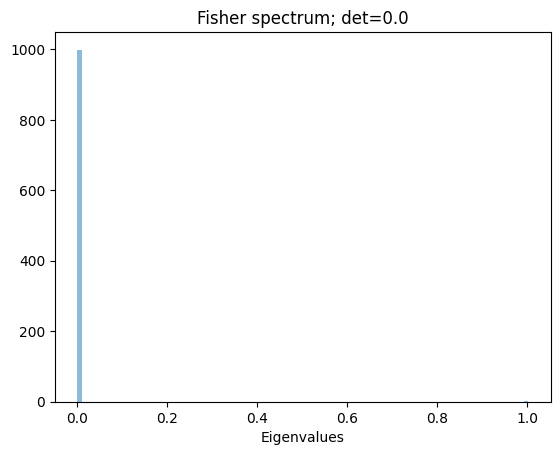

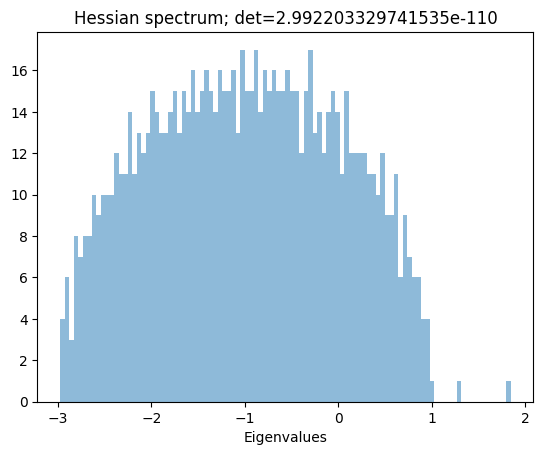

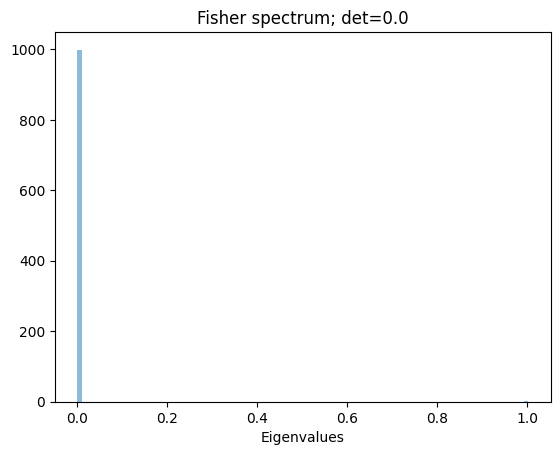

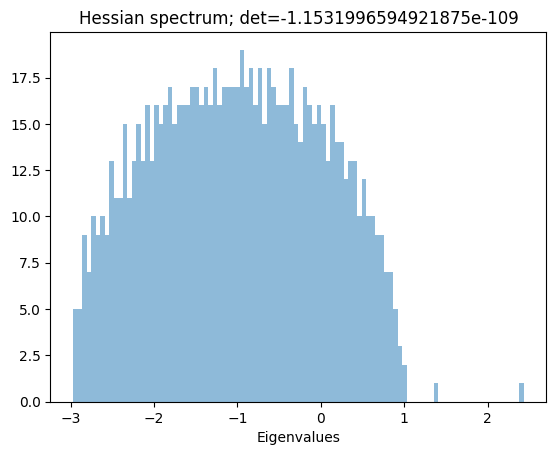

(np.float64(0.0), np.float64(-1.1531996594921875e-109))

In [148]:
N = 1000
lambda2 = 2
lambda1 = 2
mu = 1
rho = 0.2

analyse_Hess_Fisher(N, rho, lambda1, lambda2, mu,estim = True,  spectre = True)

lambda2 = 3
lambda1 = 2


analyse_Hess_Fisher(N, rho, lambda1, lambda2, mu,estim = True,  spectre = True)

c:\Users\celia\Desktop\EPFL\MA2\Physics_project\venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\celia\Desktop\EPFL\MA2\Physics_project\venv\Lib\site-packages\numpy\lib\_histograms_impl.py:853: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
c:\Users\celia\Desktop\EPFL\MA2\Physics_project\venv\Lib\site-packages\matplotlib\axes\_axes.py:7135: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


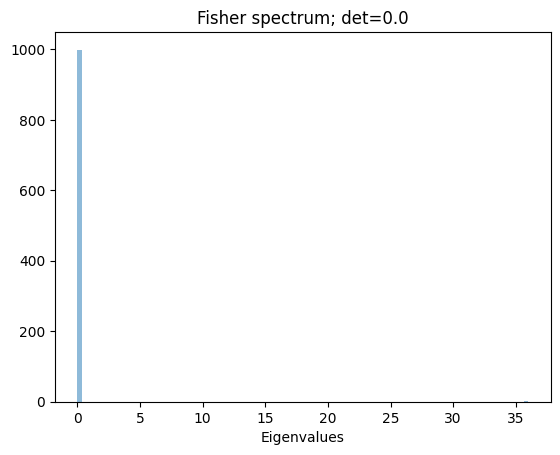

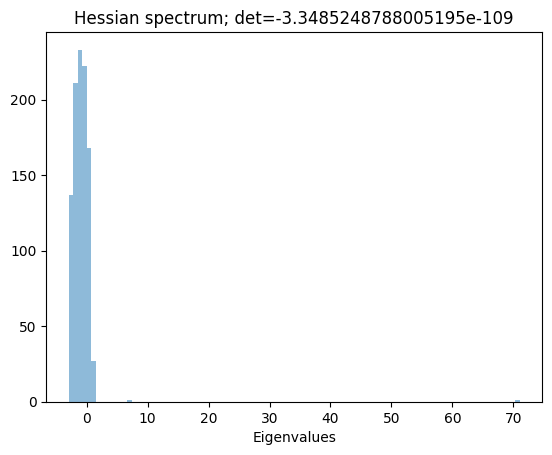

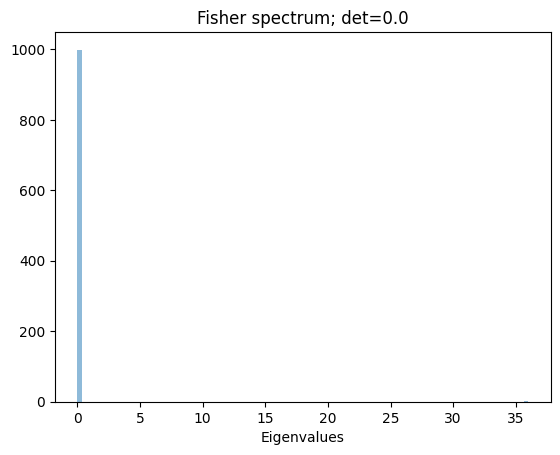

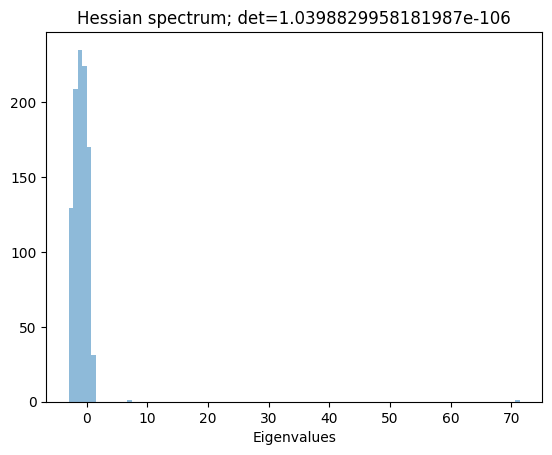

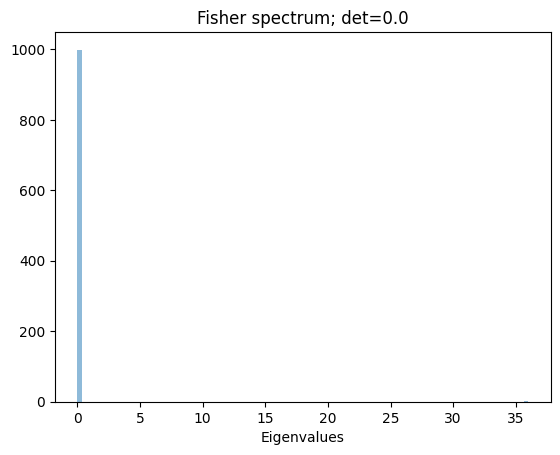

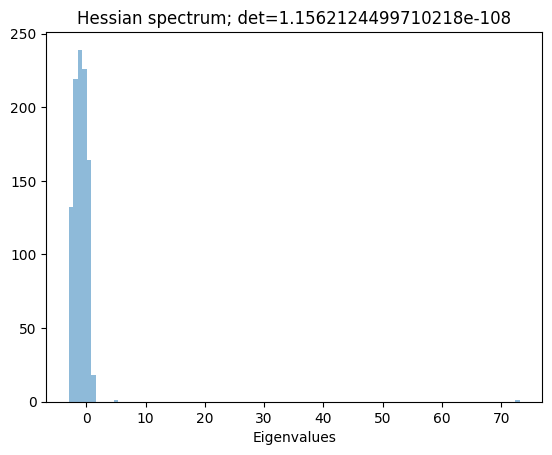

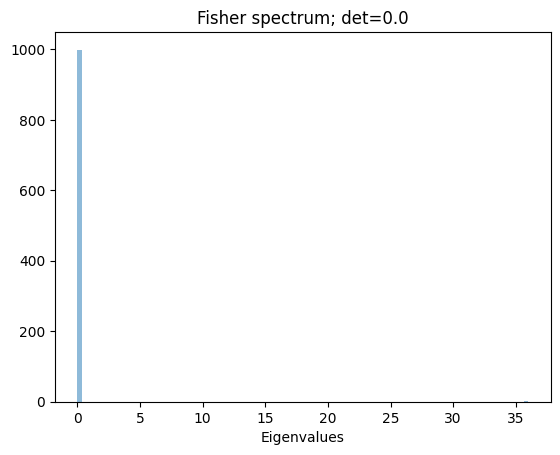

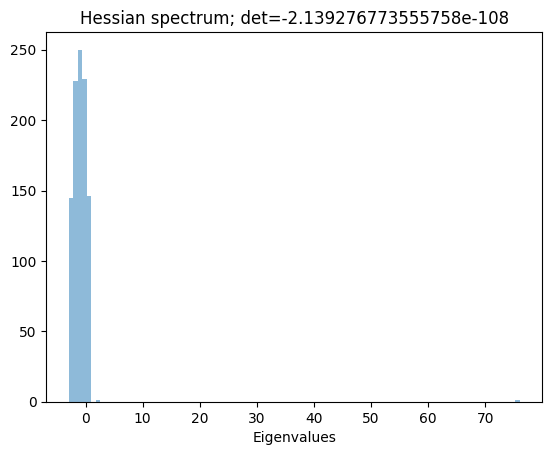

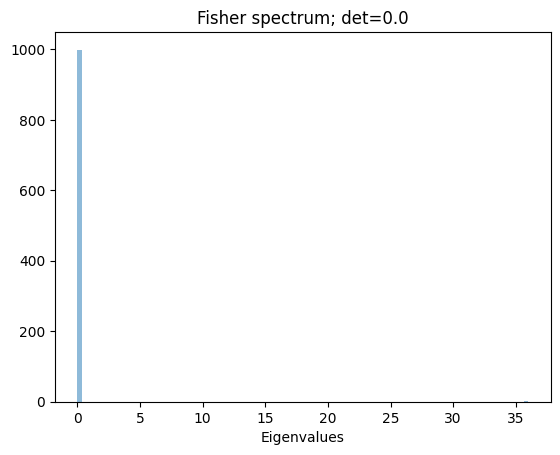

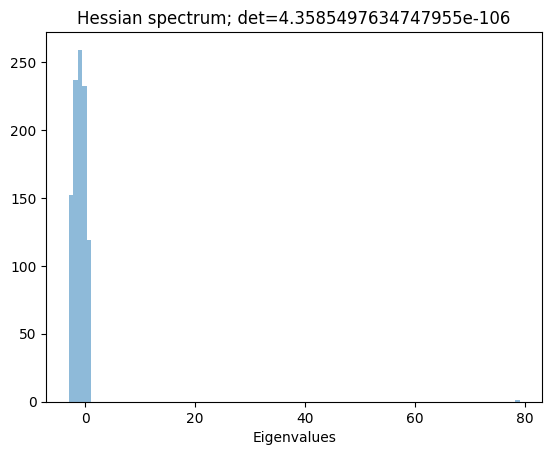

[np.float64(-3.3485248788005195e-109), np.float64(1.0398829958181987e-106), np.float64(1.1562124499710218e-108), np.float64(-2.139276773555758e-108), np.float64(4.3585497634747955e-106)]


In [71]:

Nvary = np.linspace(500, 5000, 20, dtype = int)
lambda2 = 8
lambda1 = 7
mu = 1
MU = np.linspace(0.1, 50, 20)
rho = 0.7
LAM1 = np.linspace(0.1, 5, 20)
M = 10
N = 1000
RHO = np.linspace(0, 1, 5)
DETF= []
DETH= []
for rho in RHO: 
    detF, detH = analyse_Hess_Fisher(N, rho, lambda1, lambda2, mu, spectre = True)
    DETF += [detF]
    DETH += [detH]
print(DETH)
DETF = np.array(DETF)
DETH = np.array(DETH)



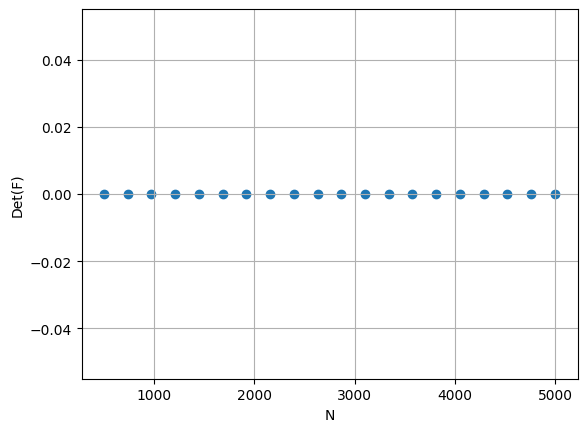

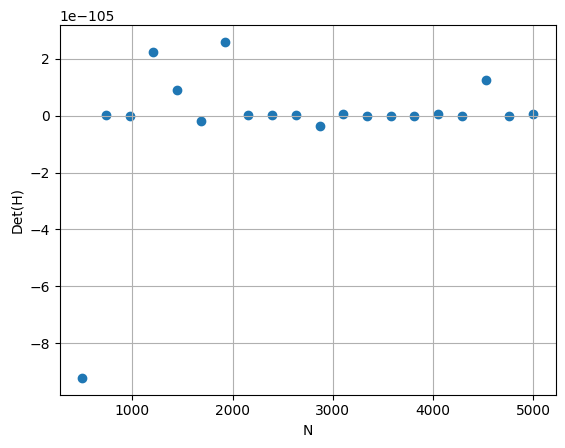

In [70]:

plt.scatter(Nvary, DETF)
plt.xlabel("N")
plt.ylabel("Det(F)")
plt.grid()
plt.show()

plt.scatter(Nvary, DETH)
plt.xlabel("N")
plt.ylabel("Det(H)")
plt.grid()
plt.show()

In [ ]:
#varry: rho, alpha, k1, k1-k2
M=10 #nb of simulation for averaging (precision)
n=100 #size of signal
k1= 5
k2= 2
alpha = np.sqrt(0.5) #Y1 plus imp que Y2
rho = 1

RHO = np.linspace(0,1,30)
K1 = np.linspace(0,5,30)

K2 = np.linspace(0,5,30)
ALPHA = np.linspace(0,1,30)

ZA1, ZB2, ZA2, ZB1 = run_experiment_2D(
    vary_param_x='k1', vary_values_x=K1,
    vary_param_y='rho',  vary_values_y=RHO,
    M=M, n=n, k1=k1, k2=k2, rho=rho, alpha=alpha,method = "fisher", methodF = "A",all_overlap= False, plot = True
)

